# Full-dataset few-shot base-model grading comparison

This notebook evaluates the enabled instruction-tuned base models on every row of `training_data_moh_eng_fewshot_v2.csv` using scored-example few-shot prompting. Thinking runs are currently disabled so only the faster non-thinking mode is evaluated.

All runs use the same few-shot prompt, deterministic decoding, scalar-score parser, dataset labels, and final-score metrics. Models are loaded with 4-bit NF4 quantization to fit the available VRAM. Each model is deleted and the CUDA cache is cleared before the next model is loaded.

The enabled benchmark runs every valid dataset row against each enabled model. Results are checkpointed after every batch and completed runs are reused when the cell is restarted.

## 1. Install inference and analysis dependencies

Recent Transformers support is required for Qwen3.8, Gemma 4, Granite 4.2, and Ornith 1.5. Restart the kernel after this cell if packages are upgraded.


In [1]:
%pip install -U "transformers>=5.16.1" accelerate bitsandbytes kernels torchvision sentencepiece pandas scikit-learn matplotlib tqdm


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 406.3 kB/s  0:00:06 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 559.5 kB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 713.6 kB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 876.4/876.4 kB 716.3 kB/s  0:00:01eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 1.5 MB/s  0:00:04 eta 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 899.9 kB/s  0:00:10 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 668.5 kB/s  0:00:07 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 965.8 kB/s  0:00:06 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 5.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 2. Imports and experiment configuration

The thinking budget is larger because reasoning tokens precede the final scalar JSON object. Greedy decoding keeps comparisons reproducible. Per-model starting batch sizes are tuned for 24 GB of VRAM, and the evaluator automatically retries with a smaller batch after a CUDA out-of-memory error.

In [1]:
import ast
import csv
import gc
import json
import math
import os
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.metrics import cohen_kappa_score
from tqdm.auto import tqdm
from transformers import (
    AutoModelForCausalLM,
    AutoModelForMultimodalLM,
    AutoProcessor,
    AutoTokenizer,
    BitsAndBytesConfig,
)

if not torch.cuda.is_available():
    raise RuntimeError("A CUDA GPU is required for this benchmark.")

# Load the Hugging Face access token without displaying its secret value.
def read_env_value(path, key):
    if not path.exists():
        raise FileNotFoundError(f"Missing environment file: {path.resolve()}")
    for raw_line in path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        name, value = line.split("=", 1)
        name = name.strip().removeprefix("export ").strip()
        if name != key:
            continue
        value = value.strip()
        if len(value) >= 2 and value[0] == value[-1] and value[0] in ("'", '"'):
            value = value[1:-1]
        return value
    return None

ENV_PATH = Path("./.env")
HF_TOKEN = read_env_value(ENV_PATH, "HF_TOKEN")
if not HF_TOKEN:
    raise RuntimeError("HF_TOKEN is missing or empty in .env.")
os.environ["HF_TOKEN"] = HF_TOKEN
print("HF_TOKEN loaded from .env.")

DATASET_PATH = Path("../Datasets/training_data_moh_eng_fewshot_v2.csv")
RESULTS_DIR = Path("./base_model_results_fewshot")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Increment this tag whenever prompts or generation settings change.
RUN_TAG = "full_dataset_fewshot_nf4_v1"
OVERWRITE_EXISTING = False

# The visible answer is short, but a larger budget leaves room for model reasoning.
THINKING_MODES = [
    False,
    # True,  # Uncomment to add thinking-mode runs.
]
MAX_NEW_TOKENS = {False: 2048, True: 2048}

MODEL_SPECS = [
    {"name": "Qwen3.5 4B", "model_id": "Qwen/Qwen3.5-4B", "loader": "multimodal", "batch_size": 16},
    {"name": "Qwen3.5 9B", "model_id": "Qwen/Qwen3.5-9B", "loader": "multimodal", "batch_size": 8},
    # {"name": "Qwen3.5 27B", "model_id": "Qwen/Qwen3.5-27B", "loader": "multimodal", "batch_size": 2},
    # {"name": "Qwen3.8 27B", "model_id": "Qwen/Qwen3.8-27B", "loader": "multimodal", "batch_size": 2},
    {"name": "Gemma 4 12B", "model_id": "google/gemma-4-12B-it", "loader": "multimodal", "batch_size": 4},
    {"name": "Granite 4.2 8B", "model_id": "ibm-granite/granite-4.2-8b", "loader": "causal_lm", "batch_size": 8},
    {"name": "Ornith 1.5 9B", "model_id": "ornith-ai/Ornith-1.5-9B", "loader": "multimodal", "batch_size": 8},
]

compute_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=compute_dtype,
)

print("PyTorch:", torch.__version__)
print("Transformers GPU:", torch.cuda.get_device_name(0))
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print("Compute dtype:", compute_dtype)
print("Models:", len(MODEL_SPECS), "| modes per model:", len(THINKING_MODES))

HF_TOKEN loaded from .env.
PyTorch: 2.14.1+cu130
Transformers GPU: NVIDIA L40S
VRAM: 44.4 GB
Compute dtype: torch.bfloat16
Models: 5 | modes per model: 1


## 3. Load and validate the full few-shot dataset

This benchmark uses every valid row in the few-shot dataset. No train/validation/test split is made, and no rubric criteria are required because the few-shot method predicts the recorded scalar score directly.

The dataset must contain the question, desired answer, student answer, maximum score, recorded student score, and one example answer for every possible score.

In [2]:
EXAMPLE_RE = re.compile(r"^Score\s+(\d+)\s*/\s*(\d+):\s*(.+)$", re.DOTALL)


def parse_int(value, column_name, minimum=0, maximum=None):
    try:
        number = float(value)
    except (TypeError, ValueError) as error:
        raise ValueError(f"{column_name} must be numeric: {value!r}") from error
    if not math.isfinite(number) or not number.is_integer():
        raise ValueError(f"{column_name} must be a whole number: {value!r}")
    result = int(number)
    if result < minimum or (maximum is not None and result > maximum):
        raise ValueError(f"{column_name} must be between {minimum} and {maximum}: {value!r}")
    return result


def parse_examples(value, max_score):
    if isinstance(value, list):
        items = value
    elif isinstance(value, str):
        try:
            items = json.loads(value)
        except json.JSONDecodeError as error:
            raise ValueError(f"examples is not valid JSON: {value[:100]!r}") from error
    else:
        raise TypeError(f"examples must be a JSON array string, got {type(value).__name__}.")

    if not isinstance(items, list) or len(items) != max_score + 1:
        raise ValueError(f"Expected {max_score + 1} examples for max_score={max_score}.")

    parsed = []
    for item in items:
        match = EXAMPLE_RE.match(str(item).strip())
        if not match:
            raise ValueError(f"Example not in 'Score X/Y: answer' format: {item!r}")
        score, out_of, answer = int(match.group(1)), int(match.group(2)), match.group(3).strip()
        if out_of != max_score or not 0 <= score <= max_score or not answer:
            raise ValueError(f"Invalid example score or answer: {item!r}")
        parsed.append((score, answer))

    scores = sorted(score for score, _ in parsed)
    if scores != list(range(max_score + 1)):
        raise ValueError(f"Examples must cover every score from 0 to {max_score}: {scores}")
    return sorted(parsed, key=lambda item: -item[0])


df = pd.read_csv(DATASET_PATH, keep_default_na=False).reset_index(drop=True)
required_columns = [
    "question", "desired_answer", "student_answer", "max_score", "student_score", "examples",
]
missing = [column for column in required_columns if column not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

records = []
validation_errors = []
for index, row in df.iterrows():
    try:
        question = str(row["question"]).strip()
        desired_answer = str(row["desired_answer"]).strip()
        max_score = parse_int(row["max_score"], "max_score", minimum=1)
        student_score = parse_int(row["student_score"], "student_score", minimum=0, maximum=max_score)
        examples = parse_examples(row["examples"], max_score)
        if not question or not desired_answer:
            raise ValueError("question and desired_answer must be nonempty")
        records.append({
            "dataset_index": int(index),
            "id": str(row["id"]) if "id" in row else str(index),
            "question": question,
            "desired_answer": desired_answer,
            "student_answer": str(row["student_answer"]),
            "max_score": max_score,
            "student_score": student_score,
            "examples": examples,
        })
    except (KeyError, TypeError, ValueError) as error:
        validation_errors.append(f"row {index}: {error}")

if validation_errors:
    raise ValueError("Dataset validation failed:\n" + "\n".join(validation_errors[:20]))

df = pd.DataFrame(records)
print("Full dataset rows:", len(df))
print("Maximum score distribution:", df["max_score"].value_counts().sort_index().to_dict())
display(df[["question", "student_answer", "max_score", "student_score", "examples"]].head())

Full dataset rows: 3778
Maximum score distribution: {1: 971, 2: 1212, 3: 813, 4: 450, 5: 332}


,question,student_answer,max_score,student_score,examples
0,What is the role of a prototype program in pro...,High risk problems are address in the prototyp...,1,0,"[(1, A prototype is a stripped-down program th..."
1,What is the role of a prototype program in pro...,To simulate portions of the desired final prod...,1,1,"[(1, A prototype is a stripped-down program th..."
2,What is the role of a prototype program in pro...,A prototype program simulates the behaviors of...,1,1,"[(1, A prototype is a stripped-down program th..."
3,What is the role of a prototype program in pro...,Defined in the Specification phase a prototype...,1,1,"[(1, A prototype is a stripped-down program th..."
4,What is the role of a prototype program in pro...,It is used to let the users have a first idea ...,1,0,"[(1, A prototype is a stripped-down program th..."


## 4. Shared few-shot grading prompt and strict output parser

The model sees the question, reference answer, student answer, and one scored example for every possible score. The final answer must be one JSON object containing only an integer `score`.

In [3]:
SYSTEM_PROMPT = (
    "You are a strict, consistent grader of short answers to computer science exam questions.\n\n"
    "Compare the student answer with the reference answer and the scored examples. "
    "Use the examples to calibrate how much partial credit each score represents.\n"
    "Accept different wording, synonyms, and correct code snippets. Do not penalize spelling, grammar, or brevity. "
    "Give no credit for vague, generic, or off-topic statements. When unsure between two scores, choose the lower one.\n\n"
    "Return ONLY a JSON object of the form {\"score\": <integer>}. "
    "The score must be a whole number from 0 through MAX SCORE. Do not include feedback, markdown, or any other text."
)


def build_messages(row):
    examples_text = "\n\n".join(
        f"Score {score}/{row['max_score']}:\n{answer}"
        for score, answer in row["examples"]
    )
    user_prompt = (
        f"Question:\n{row['question']}\n\n"
        f"Reference answer:\n{row['desired_answer']}\n\n"
        f"Scored examples (one for every possible score):\n{examples_text}\n\n"
        f"Student answer:\n{row['student_answer']}\n\n"
        f"Maximum score: {row['max_score']}\n"
        "Return JSON only."
    )
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_prompt},
    ]


def parse_prediction(raw_output, max_score):
    """Return a valid scalar score, tolerating surrounding model text."""
    candidates = []
    for match in re.findall(r"\{[^{}]*\}", raw_output):
        try:
            candidates.append(json.loads(match))
        except json.JSONDecodeError:
            continue

    for candidate in reversed(candidates):
        if not isinstance(candidate, dict) or "score" not in candidate:
            continue
        score = candidate["score"]
        if isinstance(score, bool) or not isinstance(score, (int, float)):
            continue
        if isinstance(score, float) and not score.is_integer():
            continue
        score = int(score)
        if 0 <= score <= max_score:
            return {"valid": True, "score": score, "error": None}

    return {
        "valid": False,
        "score": None,
        "error": f"No integer JSON score in range 0-{max_score} was found.",
    }

print(SYSTEM_PROMPT)

You are a strict, consistent grader of short answers to computer science exam questions.

Compare the student answer with the reference answer and the scored examples. Use the examples to calibrate how much partial credit each score represents.
Accept different wording, synonyms, and correct code snippets. Do not penalize spelling, grammar, or brevity. Give no credit for vague, generic, or off-topic statements. When unsure between two scores, choose the lower one.

Return ONLY a JSON object of the form {"score": <integer>}. The score must be a whole number from 0 through MAX SCORE. Do not include feedback, markdown, or any other text.


## 5. Model loading, thinking control, and VRAM cleanup

Multimodal model classes are used for Qwen, Gemma, and Ornith; Granite uses its causal-language-model class. Only text is supplied. The prompt is checked to ensure that each model's chat template actually changes when thinking is toggled.

In [4]:
def clear_cuda_cache():
    gc.collect()
    torch.cuda.empty_cache()
    if hasattr(torch.cuda, "ipc_collect"):
        torch.cuda.ipc_collect()


def print_vram(prefix):
    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    print(f"{prefix}: allocated={allocated:.2f} GiB, reserved={reserved:.2f} GiB")


def load_processor(model_id):
    try:
        processor = AutoProcessor.from_pretrained(
            model_id, token=HF_TOKEN, trust_remote_code=True
        )
    except (ValueError, OSError):
        processor = AutoTokenizer.from_pretrained(
            model_id, token=HF_TOKEN, trust_remote_code=True
        )
    tokenizer = getattr(processor, "tokenizer", processor)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"
    return processor, tokenizer


def load_model(spec):
    print(f"Loading {spec['name']} from {spec['model_id']}")
    processor, tokenizer = load_processor(spec["model_id"])
    model_class = (
        AutoModelForMultimodalLM
        if spec["loader"] == "multimodal"
        else AutoModelForCausalLM
    )
    model = model_class.from_pretrained(
        spec["model_id"],
        quantization_config=bnb_config,
        dtype=compute_dtype,
        device_map="auto",
        low_cpu_mem_usage=True,
        trust_remote_code=True,
        token=HF_TOKEN,
    )
    model.eval()
    if hasattr(model.config, "use_cache"):
        model.config.use_cache = True
    print_vram(f"After loading {spec['name']}")
    return model, processor, tokenizer


def render_prompt(processor, messages, thinking):
    return processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=thinking,
    )


def verify_thinking_toggle(processor):
    sample_messages = build_messages(df.iloc[0])
    direct_prompt = render_prompt(processor, sample_messages, thinking=False)
    thinking_prompt = render_prompt(processor, sample_messages, thinking=True)
    if direct_prompt == thinking_prompt:
        raise RuntimeError(
            "This model's chat template ignored enable_thinking; the two runs "
            "would not be a valid thinking/non-thinking comparison."
        )
    print("Thinking toggle verified in the chat template.")

## 6. Resumable inference and metric calculation

Each model/mode pair writes one JSONL file under `base_model_results_fewshot`. If execution is interrupted, rerunning the benchmark skips completed dataset indices. Invalid outputs count as failures for response-level and final-score accuracies. Final-score MAE/RMSE use structurally valid predictions.

In [5]:
METRIC_COLUMNS = [
    "invalid_output_rate",
    "exact_match_accuracy",
    "final_score_exact_accuracy",
    "final_score_within_one_accuracy",
    "final_score_mae",
    "final_score_rmse",
    "final_score_pearson",
    "final_score_qwk",
]


def mode_name(thinking):
    return "thinking" if thinking else "non-thinking"


def run_slug(spec, thinking):
    name = re.sub(r"[^a-z0-9]+", "_", spec["name"].lower()).strip("_")
    return f"{RUN_TAG}__{name}__{mode_name(thinking)}"


def prediction_path(spec, thinking):
    return RESULTS_DIR / f"{run_slug(spec, thinking)}.jsonl"


def load_prediction_records(path):
    if not path.exists():
        return []
    records = []
    with path.open("r", encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            if not line.strip():
                continue
            try:
                record = json.loads(line)
                record["dataset_index"] = int(record["dataset_index"])
                records.append(record)
            except (json.JSONDecodeError, KeyError, TypeError, ValueError):
                print(f"Ignoring malformed JSONL line {line_number} in {path.name}")
    by_index = {record["dataset_index"]: record for record in records}
    return [by_index[index] for index in sorted(by_index)]


def append_prediction_records(path, records):
    with path.open("a", encoding="utf-8") as handle:
        for record in records:
            handle.write(json.dumps(record, ensure_ascii=False) + "\n")
        handle.flush()
        os.fsync(handle.fileno())


def input_device_for(model):
    try:
        return model.get_input_embeddings().weight.device
    except (AttributeError, NotImplementedError):
        return next(model.parameters()).device


def generate_batch(model, processor, tokenizer, rows, thinking):
    prompts = [
        render_prompt(processor, build_messages(row), thinking=thinking)
        for row in rows
    ]
    inputs = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        add_special_tokens=False,
    )
    input_width = inputs["input_ids"].shape[1]
    device = input_device_for(model)
    inputs = {key: value.to(device) for key, value in inputs.items()}

    started = time.perf_counter()
    with torch.inference_mode():
        generated = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS[thinking],
            do_sample=False,
            use_cache=True,
            pad_token_id=tokenizer.pad_token_id,
        )
    elapsed = time.perf_counter() - started
    continuation_ids = generated[:, input_width:].detach().cpu()
    outputs = tokenizer.batch_decode(continuation_ids, skip_special_tokens=True)

    del inputs, generated, continuation_ids
    return [output.strip() for output in outputs], elapsed


def calculate_metrics(records, spec, thinking):
    if len(records) != len(df):
        raise ValueError(f"Expected {len(df)} records but found {len(records)}.")

    valid_records = [record for record in records if record["valid"]]
    errors = [abs(record["predicted_final_score"] - record["true_final_score"]) for record in valid_records]
    true_scores = [record["true_final_score"] for record in valid_records]
    predicted_scores = [record["predicted_final_score"] for record in valid_records]
    total = len(records)
    invalid_count = total - len(valid_records)

    pearson = float("nan")
    if len(valid_records) > 1 and len(set(true_scores)) > 1 and len(set(predicted_scores)) > 1:
        pearson = float(np.corrcoef(true_scores, predicted_scores)[0, 1])

    qwk = float("nan")
    if valid_records:
        try:
            qwk = float(cohen_kappa_score(true_scores, predicted_scores, weights="quadratic"))
        except Exception:
            pass

    return {
        "model": spec["name"],
        "model_id": spec["model_id"],
        "mode": mode_name(thinking),
        "examples": total,
        "valid_examples": len(valid_records),
        "invalid_output_rate": invalid_count / total if total else 0.0,
        "exact_match_accuracy": sum(
            int(record["valid"] and record["predicted_final_score"] == record["true_final_score"])
            for record in records
        ) / total if total else 0.0,
        "final_score_exact_accuracy": sum(error == 0 for error in errors) / total if total else 0.0,
        "final_score_within_one_accuracy": sum(error <= 1 for error in errors) / total if total else 0.0,
        "final_score_mae": float(np.mean(errors)) if errors else float("nan"),
        "final_score_rmse": float(np.sqrt(np.mean(np.square(errors)))) if errors else float("nan"),
        "final_score_pearson": pearson,
        "final_score_qwk": qwk,
        "generation_minutes": sum(float(record.get("generation_seconds", 0.0)) for record in records) / 60,
        "mean_generation_seconds": sum(float(record.get("generation_seconds", 0.0)) for record in records) / total if total else float("nan"),
    }


def evaluate_model_mode(model, processor, tokenizer, spec, thinking):
    path = prediction_path(spec, thinking)
    if OVERWRITE_EXISTING and path.exists():
        path.unlink()

    existing = load_prediction_records(path)
    completed = {int(record["dataset_index"]) for record in existing}
    pending = [index for index in range(len(df)) if index not in completed]
    active_batch_size = spec["batch_size"]

    print(
        f"{spec['name']} | {mode_name(thinking)}: "
        f"{len(completed)} complete, {len(pending)} remaining"
    )

    position = 0
    with tqdm(total=len(pending), desc=f"{spec['name']} | {mode_name(thinking)}") as progress:
        while position < len(pending):
            batch_indices = pending[position:position + active_batch_size]
            rows = [df.iloc[index] for index in batch_indices]
            try:
                raw_outputs, elapsed = generate_batch(
                    model, processor, tokenizer, rows, thinking
                )
            except torch.OutOfMemoryError:
                clear_cuda_cache()
                if active_batch_size == 1:
                    raise
                active_batch_size = max(1, active_batch_size // 2)
                print(f"CUDA OOM: retrying with batch size {active_batch_size}")
                continue

            seconds_per_example = elapsed / len(batch_indices)
            batch_records = []
            for dataset_index, row, raw_output in zip(batch_indices, rows, raw_outputs):
                parsed = parse_prediction(raw_output, int(row["max_score"]))
                batch_records.append({
                    "dataset_index": int(dataset_index),
                    "dataset_id": str(row["id"]),
                    "model": spec["name"],
                    "model_id": spec["model_id"],
                    "mode": mode_name(thinking),
                    "valid": parsed["valid"],
                    "error": parsed["error"],
                    "ground_truth": int(row["student_score"]),
                    "prediction": parsed["score"],
                    "max_score": int(row["max_score"]),
                    "true_final_score": int(row["student_score"]),
                    "predicted_final_score": parsed["score"],
                    "raw_output": raw_output,
                    "generation_seconds": seconds_per_example,
                })

            append_prediction_records(path, batch_records)
            position += len(batch_indices)
            progress.update(len(batch_indices))

    records = load_prediction_records(path)
    return calculate_metrics(records, spec, thinking), records

## 7. Run all models sequentially

Run this cell to start or resume the benchmark. A model is not loaded when both of its result files are already complete. In all cases, model references are deleted and the CUDA allocator cache is cleared before the next model is loaded.


In [6]:
summary_rows = []
failure_rows = []
summary_path = RESULTS_DIR / f"{RUN_TAG}__summary_metrics.csv"
failure_path = RESULTS_DIR / f"{RUN_TAG}__failures.csv"

for spec in MODEL_SPECS:
    completed_modes = {}
    modes_to_run = []

    for thinking in THINKING_MODES:
        records = load_prediction_records(prediction_path(spec, thinking))
        if not OVERWRITE_EXISTING and len(records) == len(df):
            completed_modes[thinking] = records
            summary_rows.append(calculate_metrics(records, spec, thinking))
            print(f"Reused completed run: {spec['name']} | {mode_name(thinking)}")
        else:
            modes_to_run.append(thinking)

    if modes_to_run:
        model = None
        processor = None
        tokenizer = None
        try:
            clear_cuda_cache()
            model, processor, tokenizer = load_model(spec)
            verify_thinking_toggle(processor)

            for thinking in modes_to_run:
                try:
                    metrics, _ = evaluate_model_mode(
                        model, processor, tokenizer, spec, thinking
                    )
                    summary_rows.append(metrics)
                    current_summary = (
                        pd.DataFrame(summary_rows)
                        .drop_duplicates(["model", "mode"], keep="last")
                    )
                    current_summary.to_csv(summary_path, index=False)
                    display(pd.DataFrame([metrics]).set_index(["model", "mode"]))
                except Exception as error:
                    failure_rows.append({
                        "model": spec["name"],
                        "model_id": spec["model_id"],
                        "mode": mode_name(thinking),
                        "error_type": type(error).__name__,
                        "error": str(error),
                    })
                    pd.DataFrame(failure_rows).to_csv(failure_path, index=False)
                    print(f"FAILED: {spec['name']} | {mode_name(thinking)}: {error}")
        finally:
            # Remove every live reference before loading another model.
            if model is not None:
                del model
            if processor is not None:
                del processor
            if tokenizer is not None:
                del tokenizer
            clear_cuda_cache()
            print_vram(f"After unloading {spec['name']}")

summary_df = (
    pd.DataFrame(summary_rows)
    .drop_duplicates(["model", "mode"], keep="last")
)
summary_df.to_csv(summary_path, index=False)

if failure_rows:
    display(pd.DataFrame(failure_rows))

display(summary_df.set_index(["model", "mode"]))


Loading Qwen3.5 4B from Qwen/Qwen3.5-4B


preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/7.76k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/3.16k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

...

After loading Ornith 1.5 9B: allocated=7.35 GiB, reserved=7.41 GiB
Thinking toggle verified in the chat template.
Ornith 1.5 9B | non-thinking: 0 complete, 3778 remaining


Ornith 1.5 9B | non-thinking:   0%|          | 0/3778 [00:00<?, ?it/s]

,,model_id,examples,valid_examples,invalid_output_rate,exact_match_accuracy,final_score_exact_accuracy,final_score_within_one_accuracy,final_score_mae,final_score_rmse,final_score_pearson,final_score_qwk,generation_minutes,mean_generation_seconds
model,mode,,,,,,,,,,,,,
Ornith 1.5 9B,non-thinking,ornith-ai/Ornith-1.5-9B,3778,3778,0.0,0.594759,0.594759,0.935416,0.478825,0.805125,0.733815,0.719997,5.035976,0.079978


After unloading Ornith 1.5 9B: allocated=0.01 GiB, reserved=0.05 GiB


,,model_id,examples,valid_examples,invalid_output_rate,exact_match_accuracy,final_score_exact_accuracy,final_score_within_one_accuracy,final_score_mae,final_score_rmse,final_score_pearson,final_score_qwk,generation_minutes,mean_generation_seconds
model,mode,,,,,,,,,,,,,
Qwen3.5 4B,non-thinking,Qwen/Qwen3.5-4B,3778,3778,0.000000,0.611699,0.611699,0.952620,0.440974,0.747680,0.753708,0.747120,4.137103,0.065703
Qwen3.5 9B,non-thinking,Qwen/Qwen3.5-9B,3778,3778,0.000000,0.601906,0.601906,0.941768,0.463473,0.782450,0.753761,0.740346,5.298623,0.084150
Gemma 4 12B,non-thinking,google/gemma-4-12B-it,3778,3777,0.000265,0.643727,0.643727,0.953679,0.404819,0.713536,0.769077,0.763619,10.710508,0.170098
Granite 4.2 8B,non-thinking,ibm-granite/granite-4.2-8b,3778,3778,0.000000,0.581260,0.581260,0.934357,0.491530,0.807423,0.719252,0.711390,5.366749,0.085232
Ornith 1.5 9B,non-thinking,ornith-ai/Ornith-1.5-9B,3778,3778,0.000000,0.594759,0.594759,0.935416,0.478825,0.805125,0.733815,0.719997,5.035976,0.079978


## 8. Side-by-side metric tables

The first table is a conventional long-form summary. The second places enabled modes beside one another for every metric; thinking columns appear automatically if thinking runs are re-enabled.


In [7]:
summary_path = RESULTS_DIR / f"{RUN_TAG}__summary_metrics.csv"
if not summary_path.exists():
    raise FileNotFoundError("Run Section 7 before building comparison tables.")

summary_df = pd.read_csv(summary_path)
model_order = [spec["name"] for spec in MODEL_SPECS]
summary_df["model"] = pd.Categorical(summary_df["model"], model_order, ordered=True)
summary_df = summary_df.sort_values(["model", "mode"]).reset_index(drop=True)

display(
    summary_df[["model", "mode", *METRIC_COLUMNS]]
    .set_index(["model", "mode"])
    .style.format("{:.4f}")
)

side_by_side_df = (
    summary_df.set_index(["model", "mode"])[METRIC_COLUMNS]
    .unstack("mode")
)
display(side_by_side_df.style.format("{:.4f}"))

side_by_side_df.to_csv(RESULTS_DIR / f"{RUN_TAG}__side_by_side_metrics.csv")


,,invalid_output_rate,exact_match_accuracy,final_score_exact_accuracy,final_score_within_one_accuracy,final_score_mae,final_score_rmse,final_score_pearson,final_score_qwk
model,mode,,,,,,,,
Qwen3.5 4B,non-thinking,0.0000,0.6117,0.6117,0.9526,0.4410,0.7477,0.7537,0.7471
Qwen3.5 9B,non-thinking,0.0000,0.6019,0.6019,0.9418,0.4635,0.7825,0.7538,0.7403
Gemma 4 12B,non-thinking,0.0003,0.6437,0.6437,0.9537,0.4048,0.7135,0.7691,0.7636
Granite 4.2 8B,non-thinking,0.0000,0.5813,0.5813,0.9344,0.4915,0.8074,0.7193,0.7114
Ornith 1.5 9B,non-thinking,0.0000,0.5948,0.5948,0.9354,0.4788,0.8051,0.7338,0.7200


,invalid_output_rate,exact_match_accuracy,final_score_exact_accuracy,final_score_within_one_accuracy,final_score_mae,final_score_rmse,final_score_pearson,final_score_qwk
mode,non-thinking,non-thinking,non-thinking,non-thinking,non-thinking,non-thinking,non-thinking,non-thinking
model,,,,,,,,
Qwen3.5 4B,0.0000,0.6117,0.6117,0.9526,0.4410,0.7477,0.7537,0.7471
Qwen3.5 9B,0.0000,0.6019,0.6019,0.9418,0.4635,0.7825,0.7538,0.7403
Gemma 4 12B,0.0003,0.6437,0.6437,0.9537,0.4048,0.7135,0.7691,0.7636
Granite 4.2 8B,0.0000,0.5813,0.5813,0.9344,0.4915,0.8074,0.7193,0.7114
Ornith 1.5 9B,0.0000,0.5948,0.5948,0.9354,0.4788,0.8051,0.7338,0.7200


## 9. Performance graphs

Final-score accuracy and correlation are higher-is-better. Invalid-output rate, MAE, and RMSE are lower-is-better.

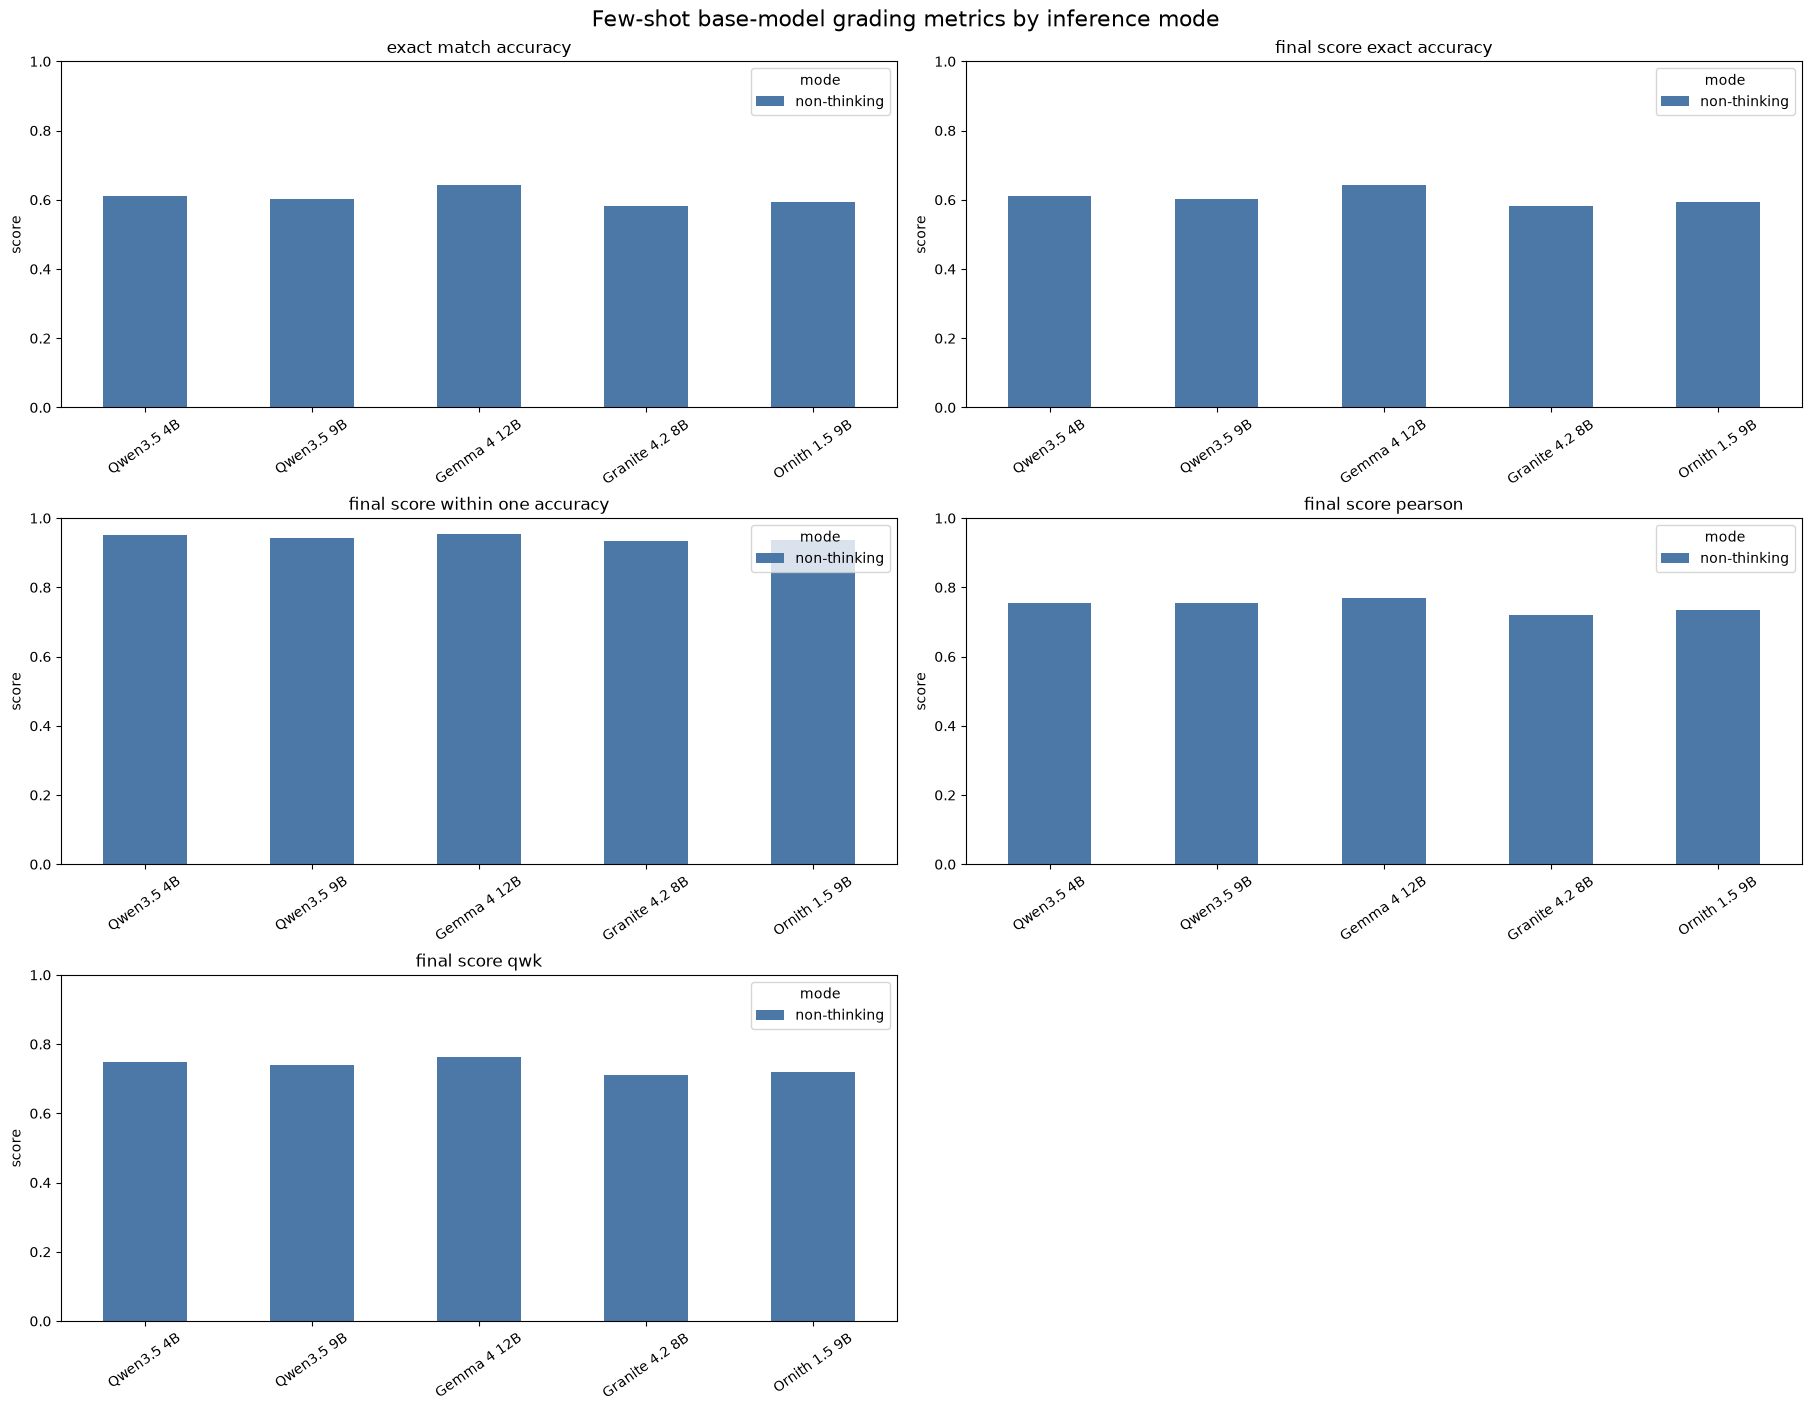

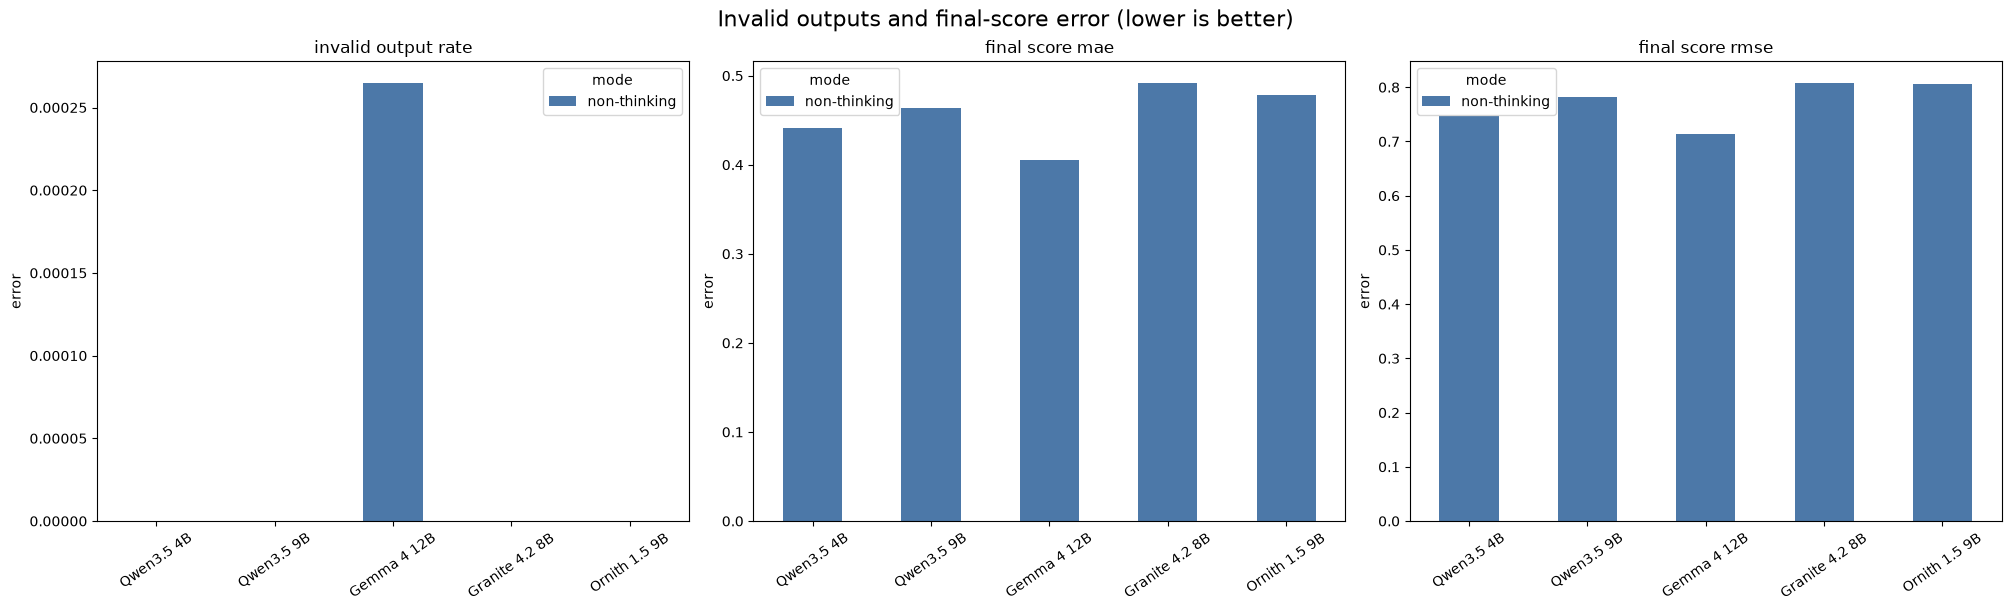

Thinking-delta graph skipped because thinking runs are disabled.


In [8]:
accuracy_metrics = [
    "exact_match_accuracy",
    "final_score_exact_accuracy",
    "final_score_within_one_accuracy",
    "final_score_pearson",
    "final_score_qwk",
]

fig, axes = plt.subplots(3, 2, figsize=(18, 14), constrained_layout=True)
for axis, metric in zip(axes.flat, accuracy_metrics):
    chart = summary_df.pivot(index="model", columns="mode", values=metric).reindex(model_order)
    chart.plot(kind="bar", ax=axis, color=["#4C78A8", "#F58518"])
    axis.set_title(metric.replace("_", " "))
    axis.set_xlabel("")
    axis.set_ylabel("score")
    axis.set_ylim(0, 1)
    axis.tick_params(axis="x", rotation=35)
    axis.legend(title="mode")

for i in range(len(accuracy_metrics), len(axes.flat)):
    axes.flat[i].axis("off")

fig.suptitle("Few-shot base-model grading metrics by inference mode", fontsize=16)
fig.savefig(RESULTS_DIR / f"{RUN_TAG}__accuracy_metrics.png", dpi=160, bbox_inches="tight")
plt.show()

error_metrics = ["invalid_output_rate", "final_score_mae", "final_score_rmse"]
fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
for axis, metric in zip(axes, error_metrics):
    chart = summary_df.pivot(index="model", columns="mode", values=metric).reindex(model_order)
    chart.plot(kind="bar", ax=axis, color=["#4C78A8", "#F58518"])
    axis.set_title(metric.replace("_", " "))
    axis.set_xlabel("")
    axis.set_ylabel("error")
    axis.tick_params(axis="x", rotation=35)
    axis.legend(title="mode")
fig.suptitle("Invalid outputs and final-score error (lower is better)", fontsize=16)
fig.savefig(RESULTS_DIR / f"{RUN_TAG}__error_metrics.png", dpi=160, bbox_inches="tight")
plt.show()

available_modes = set(summary_df["mode"])
if {"non-thinking", "thinking"}.issubset(available_modes):
    delta_metrics = [
        "exact_match_accuracy", "final_score_exact_accuracy", "final_score_pearson", "final_score_qwk"
    ]
    delta_columns = []
    for metric in delta_metrics:
        pivot = summary_df.pivot(index="model", columns="mode", values=metric).reindex(model_order)
        delta_columns.append((pivot["thinking"] - pivot["non-thinking"]).rename(metric))
    thinking_delta_df = pd.concat(delta_columns, axis=1)
    axis = thinking_delta_df.plot(kind="bar", figsize=(16, 7))
    axis.axhline(0, color="black", linewidth=1)
    axis.set_title("Thinking-mode change relative to non-thinking")
    axis.set_ylabel("thinking minus non-thinking")
    axis.set_xlabel("")
    axis.tick_params(axis="x", rotation=35)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"{RUN_TAG}__thinking_delta.png", dpi=160, bbox_inches="tight")
    plt.show()
    display(thinking_delta_df.round(4))
else:
    print("Thinking-delta graph skipped because thinking runs are disabled.")